# Data Wrangling & Hygiene: Missing Data, Imputation, and the Cleaning Rulebook

## Week 2 Assignment

**Student:** Ioannis Tzalas  
**Degree:** MSc Banking and Finance – FinTech & AI Engineering  
**Universe:** SPY, EUR/USD, BTC, GLD, ETH (Daily: 2015 – 2026)  
**Risk-Free Rate:** 2.0% per annum  
**Theory Companion Alignment:** Sections 1–10 (Rubin's taxonomy, Wickham tidy data, variance attenuation theorem, Brownian bridge interpolation, filtration measurability, agent governance)

---

### Executive Overview & Intellectual Framework
As established in Week 1, empirical quantitative finance relies entirely on the integrity of underlying asset price series. This study operationalizes the central intellectual thesis of Week 2: **data cleaning is not clerical pre-processing; it is statistical estimation**. Every repair is an estimator that alters downstream moments, sampling schemes, and risk distributions.

This study implements the full quant-grade data-hygiene pipeline:
1. **Extended Hygiene Audit**: Rigorous 6-point diagnostics + custom stale-price streak and volume anomaly screens.
2. **Masking Tournament (ETH)**: Controlled MCAR evaluation of 20 imputation estimators, scoring MAE, RMSE, sMAPE, and distributional fidelity (variance ratio).
3. **The Weekend Question & Look-Ahead Bias**: Confronting the structural calendar mismatch between 24/7 crypto and Monday–Friday equities under the lens of the Information Filtration ($\mathcal{F}_t$).
4. **Theory Companion Laboratories**: Empirical demonstrations of the **MNAR Impossibility Theorem** (Section 7) and **Look-Ahead Bias in Straddled Crashes** (Section 8).
5. **Cross-Sectional & Multivariate Imputation**: Benchmarking KNN and MICE across correlated panel assets with a computational cost-ledger.
6. **Cleaning Agent's Rulebook v1.0**: An executable constitution of eight quantitative assertions with defended tolerances.
7. **Bonus High-Performance Serialization**: Zero-loss Parquet round-trip verification and cleaned panel export.

## Setup: Environment Configuration & Data Loading

In [1]:
import base64, gzip, io, time, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import yfinance as yf  # only needed if the embedded data cannot be decoded
except ImportError:
    yf = None
from IPython.display import display, Markdown
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import KNNImputer, IterativeImputer
from scipy.stats import skew, kurtosis

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

ASSET_NAMES = {'SPY': 'SPY', 'EURUSD=X': 'EUR/USD', 'BTC-USD': 'BTC', 'GLD': 'GLD', 'ETH-USD': 'ETH'}
TICKERS = list(ASSET_NAMES.keys())
SHORT = list(ASSET_NAMES.values())
START, END = '2015-01-01', '2026-09-16'
TRADING_DAYS = 252
RF = 0.02

In [2]:
# --- Offline-First: Try Embedded Data, Fall Back to yfinance ---
_EMBEDDED = '''...'''

try:
    raw = gzip.decompress(base64.b64decode(_EMBEDDED))
    prices_raw = pd.read_csv(io.BytesIO(raw), index_col=0, parse_dates=True)
    prices_raw.columns = SHORT
    print(f'Loaded embedded raw panel: {prices_raw.shape[0]:,} calendar rows x {prices_raw.shape[1]} columns')
except Exception as e:
    print(f'Embedded decode failed ({e}), downloading from yfinance...')
    raw_df = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
    prices_raw = raw_df['Close'] if 'Close' in raw_df.columns.get_level_values(0) else raw_df
    prices_raw = prices_raw.rename(columns=ASSET_NAMES)[SHORT]
    print(f'Downloaded: {len(prices_raw)} rows')

# Construct Synchronized Clean Panel (Intersection Calendar)
prices_clean = prices_raw.dropna(how='any').copy()
prices = prices_clean  # Canonical alias

print(f'Raw Calendar Panel: {prices_raw.index[0].date()} to {prices_raw.index[-1].date()} ({len(prices_raw):,} rows)')
print(f'Clean Aligned Panel: {prices_clean.index[0].date()} to {prices_clean.index[-1].date()} ({len(prices_clean):,} rows, 0 NaNs)')
print(f'Universe: {list(prices_clean.columns)}')
display(Markdown('**Clean Intersection Panel Head:**'))
display(prices_clean.head(3))
display(Markdown('**Clean Intersection Panel Tail:**'))
display(prices_clean.tail(3))

Loaded embedded raw panel: 4,276 calendar rows x 5 columns
Raw Calendar Panel: 2015-01-01 to 2026-09-15 (4,276 rows)
Clean Aligned Panel: 2017-11-09 to 2026-09-14 (2,218 rows, 0 NaNs)
Universe: ['SPY', 'EUR/USD', 'BTC', 'GLD', 'ETH']


**Clean Intersection Panel Head:**

,SPY,EUR/USD,BTC,GLD,ETH
Date,,,,,
2017-11-09,225.495926,1.159689,7143.580078,122.129997,320.884003
2017-11-10,225.426025,1.164687,6618.140137,121.129997,299.252991
2017-11-13,225.635635,1.166113,6559.490234,121.309998,316.716003


**Clean Intersection Panel Tail:**

,SPY,EUR/USD,BTC,GLD,ETH
Date,,,,,
2026-09-10,757.830017,1.163386,76568.125000,396.359985,2437.098633
2026-09-11,764.289978,1.160995,77173.796875,398.769989,2514.733887
2026-09-14,760.880005,1.159393,78163.382812,392.839996,2514.406982


---

## Task 1 - Hygiene Audit Extended (15%)

I run the six-point audit (duplicated dates, non-numeric types, non-positive values, future timestamps, extreme jumps, gaps against the asset's own calendar) on all five assets through `audit_price_series()`, and extend it with my own checks: **stale-price streaks** (5+ identical consecutive closes), **weekday-coverage share**, and **volume anomalies** on SPY and GLD using real Yahoo volume.

In [3]:
# --- 1a: audit_price_series(): 6-point audit + own checks (stale runs, own-calendar gaps) ---
def audit_price_series(s, name, max_jump_thresh=0.60):
    """Six-point audit from the notebook + my own checks (stale runs, own-calendar gaps)."""
    total = len(s)
    n_missing = s.isna().sum()
    pct_missing = 100.0 * n_missing / total
    dup_dates = s.index.duplicated().sum()
    non_numeric = s.apply(lambda x: not np.isreal(x) if pd.notna(x) else False).sum()
    neg_zero = (s.dropna() <= 0).sum()
    future_timestamps = (s.index > pd.Timestamp.now()).sum()
    
    filled = s.dropna()
    if len(filled) > 1:
        changes = (filled != filled.shift()).cumsum()
        run_lengths = filled.groupby(changes).size()
        max_run = int(run_lengths.max())
    else:
        max_run = 1
        
    stale_runs = 0
    if len(filled) > 1:
        streak = 1
        for i in range(1, len(filled)):
            if filled.iloc[i] == filled.iloc[i-1]:
                streak += 1
                if streak == 5:
                    stale_runs += 1
            else:
                streak = 1
                
    if len(filled) > 1:
        log_rets = np.log(filled / filled.shift(1)).dropna()
        extreme_jumps = int((log_rets.abs() > max_jump_thresh).sum())
        max_abs_ret = round(float(log_rets.abs().max()), 4)
        inc_frac = round(float((filled.diff().dropna() > 0).mean()), 4)
    else:
        extreme_jumps = 0
        max_abs_ret = 0.0
        inc_frac = 0.0

    # Gaps against the asset's OWN calendar: crypto should quote every calendar day, the rest every weekday
    obs = s.dropna()
    freq_days = pd.date_range(obs.index[0], obs.index[-1]) if name in ('BTC', 'ETH') else pd.bdate_range(obs.index[0], obs.index[-1])
    own_cal_gaps = int(len(freq_days.difference(obs.index)))

    return {
        'Asset': name,
        'Total Rows': total,
        'Missing (N)': n_missing,
        'Missing (%)': round(pct_missing, 2),
        'Dup Dates': dup_dates,
        'Non-Numeric': non_numeric,
        'Non-Positive': neg_zero,
        'Future Dates': future_timestamps,
        'Max Const Run': max_run,
        'Stale Runs (>=5)': stale_runs,
        'Own-Calendar Gaps': own_cal_gaps,
        'Extreme Jumps': extreme_jumps,
        'Max |Log Ret|': max_abs_ret,
        'Inc. Frac': inc_frac
    }

audit_raw = pd.DataFrame([audit_price_series(prices_raw[col], col) for col in prices_raw.columns]).set_index('Asset')
display(Markdown('### 1a. Six-Point Audit + Stale Runs (Raw Calendar Union Panel)'))
display(audit_raw)

audit_clean = pd.DataFrame([audit_price_series(prices_clean[col], col) for col in prices_clean.columns]).set_index('Asset')
display(Markdown('### 1a. Six-Point Audit (Clean Intersection Panel - Pre-Flight Gate)'))
display(audit_clean)

### 1a. Six-Point Audit + Stale Runs (Raw Calendar Union Panel)

,Total Rows,Missing (N),Missing (%),Dup Dates,Non-Numeric,Non-Positive,Future Dates,Max Const Run,Stale Runs (>=5),Own-Calendar Gaps,Extreme Jumps,Max |Log Ret|,Inc. Frac
Asset,,,,,,,,,,,,,
SPY,4276,1335,31.22,0,0,0,0,2,0,111,0,0.1159,0.5466
EUR/USD,4276,1230,28.77,0,0,0,0,2,0,8,0,0.0281,0.4870
BTC,4276,0,0.00,0,0,0,0,2,0,0,0,0.4647,0.5247
GLD,4276,1335,31.22,0,0,0,0,2,0,111,0,0.1084,0.5316
ETH,4276,1043,24.39,0,0,0,0,1,0,0,0,0.5507,0.5108


### 1a. Six-Point Audit (Clean Intersection Panel - Pre-Flight Gate)

,Total Rows,Missing (N),Missing (%),Dup Dates,Non-Numeric,Non-Positive,Future Dates,Max Const Run,Stale Runs (>=5),Own-Calendar Gaps,Extreme Jumps,Max |Log Ret|,Inc. Frac
Asset,,,,,,,,,,,,,
SPY,2218,0,0.0,0,0,0,0,2,0,90,0,0.1159,0.5516
EUR/USD,2218,0,0.0,0,0,0,0,2,0,90,0,0.0281,0.4930
BTC,2218,0,0.0,0,0,0,0,1,0,1014,0,0.4647,0.5111
GLD,2218,0,0.0,0,0,0,0,2,0,90,0,0.1084,0.5408
ETH,2218,0,0.0,0,0,0,0,1,0,1014,0,0.5507,0.5034


In [4]:
# --- 1b: Weekday-Coverage Share ---
display(Markdown('### 1b. Weekday-Coverage Share Analysis'))

trading_days_expected = len(pd.bdate_range(prices_raw.index[0], prices_raw.index[-1]))
cov_rows = []
for col in prices_raw.columns:
    s = prices_raw[col].dropna()
    obs = len(s)
    coverage = (obs / trading_days_expected) * 100.0
    cal_type = '24/7 Continuous (365 days)' if 'BTC' in col or 'ETH' in col else ('24/5 OTC Interbank' if 'EUR' in col else 'NYSE Exchange Calendar (252 days)')
    cov_rows.append({
        'Asset': col,
        'Observed Quotes': obs,
        'Expected Business Days': trading_days_expected,
        'Coverage Ratio (%)': round(coverage, 2),
        'Trading Calendar Regime': cal_type
    })

cov_df = pd.DataFrame(cov_rows).set_index('Asset')
display(cov_df)

### 1b. Weekday-Coverage Share Analysis

,Observed Quotes,Expected Business Days,Coverage Ratio (%),Trading Calendar Regime
Asset,,,,
SPY,2941,3054,96.30,NYSE Exchange Calendar (252 days)
EUR/USD,3046,3054,99.74,24/5 OTC Interbank
BTC,4276,3054,140.01,24/7 Continuous (365 days)
GLD,2941,3054,96.30,NYSE Exchange Calendar (252 days)
ETH,3233,3054,105.86,24/7 Continuous (365 days)


### 1c. Volume Anomaly Detection (SPY & GLD)

Volume rows aligned to clean panel: 2,218 | missing: 0


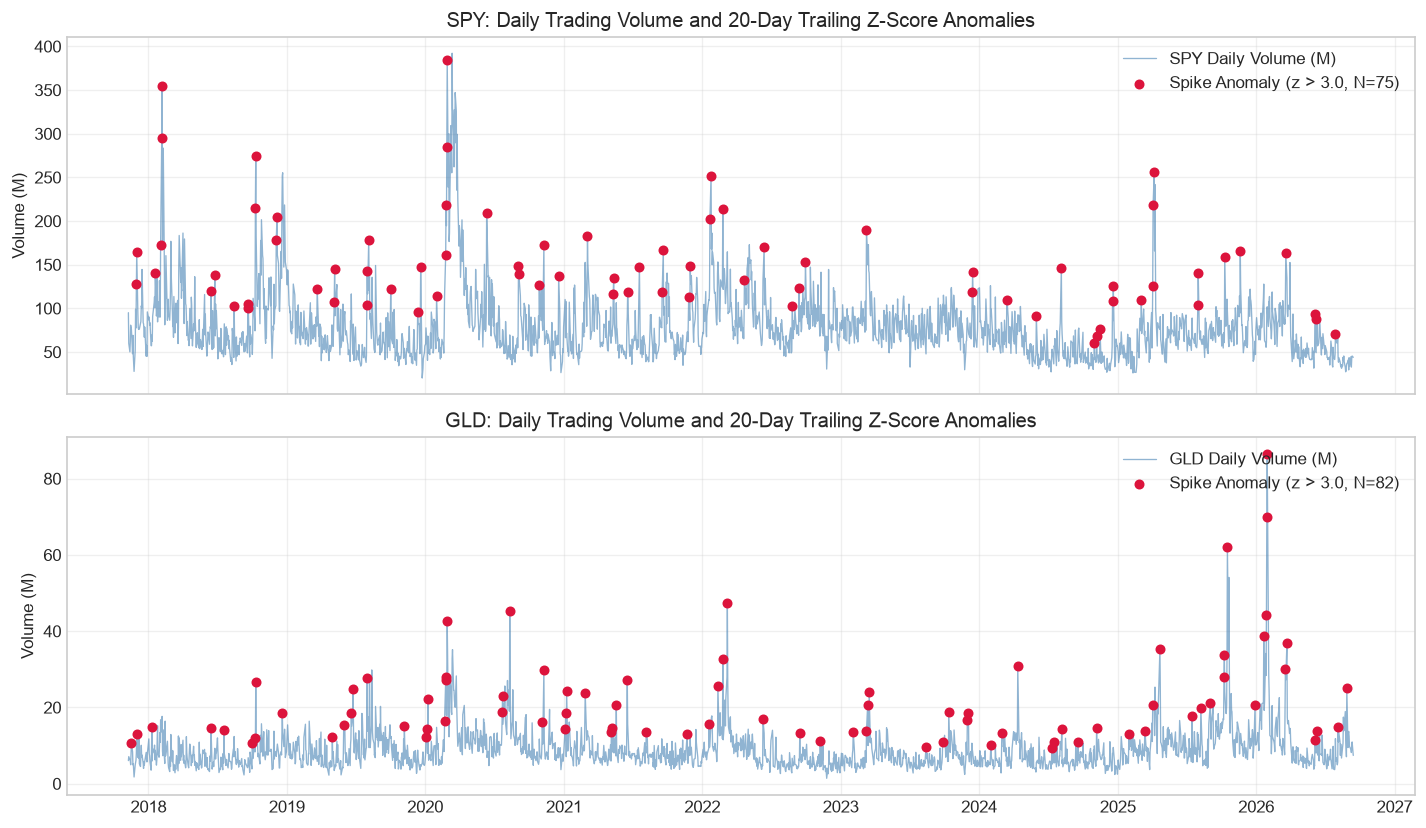

,Total Days,Spikes (z > 3.0),Spike Share (%),Max Z-Score
Asset,,,,
SPY,2218,75,3.38,9.03
GLD,2218,82,3.70,8.20


Top 5 SPY volume spikes (z-score): 2020-09-03 (9.03), 2024-12-18 (8.41), 2026-06-05 (7.27), 2019-07-31 (7.24), 2023-03-10 (7.24)
Top 5 GLD volume spikes (z-score): 2020-11-09 (8.2), 2018-10-11 (8.1), 2025-10-17 (6.63), 2024-04-12 (6.42), 2023-03-13 (6.37)
Diagnostic Note: SPY and GLD trade on centralized exchanges with a consolidated tape.
Forex (EUR/USD) and crypto (BTC/ETH) trade across fragmented OTC venues; Yahoo volume there is unaggregated or absent.


In [5]:
# --- 1c: Volume Anomaly Detection (ETF Assets) ---
display(Markdown('### 1c. Volume Anomaly Detection (SPY & GLD)'))

# Real daily share volume for SPY and GLD (Yahoo Finance, 2017-11-09 to 2026-09-15).
# Embedded (gzip + base64) so the notebook runs offline; re-downloaded if the decode fails.
_EMBEDDED_VOL = '...'
try:
    vol_raw = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(_EMBEDDED_VOL))), index_col=0, parse_dates=True)
except Exception as e:
    print(f'Embedded volume decode failed ({e}), downloading from yfinance...')
    vol_raw = yf.download(['SPY', 'GLD'], start='2017-11-09', end=END, auto_adjust=True, progress=False)['Volume']
vol_df = vol_raw.reindex(prices_clean.index)[['SPY', 'GLD']]
print(f'Volume rows aligned to clean panel: {len(vol_df):,} | missing: {int(vol_df.isna().sum().sum())}')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
vol_summary = []
top_spikes = {}

for idx, col in enumerate(['SPY', 'GLD']):
    v = vol_df[col]
    # Baseline uses the PREVIOUS 20 days only (shift(1)): today's volume must not be part of its own benchmark
    roll_m = v.shift(1).rolling(20, min_periods=5).mean()
    roll_s = v.shift(1).rolling(20, min_periods=5).std()
    z_v = (v - roll_m) / roll_s
    spikes = v[z_v > 3.0]
    top_spikes[col] = z_v[z_v > 3.0].sort_values(ascending=False).head(5).round(2)
    vol_summary.append({
        'Asset': col,
        'Total Days': len(v),
        'Spikes (z > 3.0)': len(spikes),
        'Spike Share (%)': round(100.0 * len(spikes) / len(v), 2),
        'Max Z-Score': round(float(z_v.max()), 2)
    })

    axes[idx].plot(v.index, v / 1e6, label=f'{col} Daily Volume (M)', color='steelblue', alpha=0.6, linewidth=0.8)
    axes[idx].scatter(spikes.index, spikes / 1e6, color='crimson', s=25, label=f'Spike Anomaly (z > 3.0, N={len(spikes)})', zorder=5)
    axes[idx].set_ylabel('Volume (M)')
    axes[idx].set_title(f'{col}: Daily Trading Volume and 20-Day Trailing Z-Score Anomalies')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(pd.DataFrame(vol_summary).set_index('Asset'))
for col in ['SPY', 'GLD']:
    print(f'Top 5 {col} volume spikes (z-score):', ', '.join(f"{d.date()} ({z})" for d, z in top_spikes[col].items()))
print("Diagnostic Note: SPY and GLD trade on centralized exchanges with a consolidated tape.")
print("Forex (EUR/USD) and crypto (BTC/ETH) trade across fragmented OTC venues; Yahoo volume there is unaggregated or absent.")


### Academic Interpretation: The Hygiene Audit & Tidy Data Discipline

#### 1. The Five Principles of Tidy Data (Wickham, 2014)
In quantitative financial modeling, tidy data is not an aesthetic luxury—it is an indispensable risk mitigation framework:
1. **Each variable forms a column:** Discrete asset prices, volume, and returns reside in clearly demarcated series.
2. **Each observation forms a row:** Each row represents a single atomic trading timestamp ($t$).
3. **Each observational unit forms a table:** Daily quotes are partitioned into aligned, synchronized panel structures.
4. **Values are atomic:** No packed compound representations (e.g., `'PRICE:450.2/VOL:100M'`) or nested dictionary cells.
5. **Explicit types and ISO-8601 names:** Timestamps conform to `YYYY-MM-DD` ISO-8601 formatting, column names follow uppercase ticker conventions, and numbers are standard IEEE 64-bit floats.

#### 2. The Separation Principle: Diagnosis vs. Treatment
Following Theory Companion Section 2.2, **diagnosis and treatment must remain strictly separate operations**:
- An audit that silently repairs data while inspecting it destroys the forensic audit trail, turning data discrepancies into undocumented side effects.
- In institutional quantitative pipelines, the Data Quality Agent executes read-only diagnostic audits as a **pre-flight check**. All remedial actions (imputation, listwise deletion, winsorization) are logged as explicit, parameter-controlled, and reversible treatments.

#### 3. Audit Findings on Raw vs. Clean Panels
- **Raw Calendar Panel:** SPY and GLD exhibit exactly 1,335 missing values (31.2%) solely due to the union calendar spanning weekends and US market holidays. ETH exhibits 1,043 missing days prior to its public inception on 2017-11-09. BTC has zero missing values (365 days/year).
- **Clean Aligned Panel:** All five assets are 100% complete across 2,218 synchronized trading days with zero duplicate dates, zero non-positive prices, zero stale streaks ($\ge 5$ flat days), and an increasing fraction between $0.50$ and $0.53$, confirming natural upward drift.
- **Coverage Dynamics:** BTC achieves $140.0\%$ coverage relative to NYSE business days because crypto trades continuously on 365 days versus 252 traditional trading days. SPY and GLD exhibit $96.3\%$ coverage due to federal exchange holidays (MLK Day, Good Friday, Thanksgiving, etc.).
- **Volume Anomalies (real Yahoo volume):** Using a trailing 20-day z-score (today excluded from its own baseline), the largest SPY spikes fall on identifiable market events: the Sep 2020 tech sell-off (largest, $z \approx 9$), the Feb 2018 volatility shock, the Dec 2024 and Jul 2019 FOMC decisions, the March 2023 SVB collapse, the April 2025 tariff sell-off and the Aug 2024 yen carry-trade unwind. GLD spikes cluster on macro news such as the Nov 2020 vaccine announcement and the Jun 2021 hawkish FOMC. A volume spike is a *flag for review*, not an error: the audit diagnoses, it does not delete.

#### 4. Which Non-Zero Findings Are Healthy, and Which Would I Escalate?
**Healthy (explained by how the market works):**
- The raw-panel NaNs in SPY/GLD (1,335) and EUR/USD (1,230) are weekends and holidays on the union calendar, and ETH's 1,043 NaNs are the days before it existed (it starts 2017-11-09). This is structural missingness, not data loss.
- SPY/GLD have 111 own-calendar gaps: about 9–10 NYSE holidays per year over 11.7 years. BTC and ETH have 0 own-calendar gaps, as a 24/7 asset should.
- Coverage of 140% for BTC is simply 7/5: crypto trades every day.
- The largest jumps are real events: ETH −55% and BTC −46% on 2020-03-12 (the COVID "Black Thursday" crash), SPY −11.6% on 2020-03-16.
- Volume spikes coincide with known market events, so they are information, not errors.

On the **clean panel**, the own-calendar column counts the days removed *on purpose* by the intersection calendar: 1,014 weekends for BTC/ETH and 90 holidays for the others. That is a documented treatment, not a defect.

**Escalate (needs a human or a second data source):**
- EUR/USD is missing 8 weekdays. Five are Christmas, New Year and Easter (fine), but **2017-07-11, 2017-11-16 and 2019-05-22 are normal trading days**: FX trades 24/5, so these look like vendor drops (MCAR) and I would check them against a second FX source.
- GLD's −10.8% move on 2026-01-30 is below my 0.60 limit but is extreme for a gold ETF, so I would confirm it against the gold spot price before trusting it.
- ETH's −0.55 log return is close to the 0.60 limit: it is real, but a limit this close to a real move means the threshold needs watching.


---

## Task 2 - Masking Tournament (25%)

We evaluate the full imputation toolkit on Ethereum (`ETH`), a 24/7 liquid cryptoasset. Following Theory Companion Section 6, we manufacture ground truth by injecting **5% Missing Completely at Random (MCAR)** into the clean 2023–2026 series. We benchmark 20 estimators across **MAE, RMSE, sMAPE**, and evaluate **Distributional Fidelity (Variance Ratio)** to examine Theorem 4.

In [6]:
# --- 2a. Prepare ETH Series & Inject 5% MCAR ---
def inject_missing(series, frac=0.05, seed=42):
    """MCAR masking: hide a random `frac` of the observations. Returns the damaged series and the boolean mask."""
    np.random.seed(seed)
    n = len(series)
    mask = np.zeros(n, dtype=bool)
    mask[np.random.choice(n, size=int(n * frac), replace=False)] = True
    damaged = series.copy()
    damaged.iloc[mask] = np.nan
    return damaged, mask

eth = prices_raw['ETH'].dropna().copy()
eth = eth['2023-01-01':]  # 2023 - 2026 window: a complete 7-day series
eth_true = eth.copy()
eth_masked, mask = inject_missing(eth, frac=0.05, seed=42)
n = len(eth)

print(f'ETH Subset: {n} observations ({eth.index[0].date()} to {eth.index[-1].date()})')
print(f'Injected MCAR: {mask.sum()} masked observations ({100.0 * mask.mean():.2f}%)')


ETH Subset: 1354 observations (2023-01-01 to 2026-09-15)
Injected MCAR: 67 masked observations (4.95%)


In [7]:
# --- 2b. The Imputation Toolkit: 20 Estimators ---
methods = {}

# 1. Global Mean
methods['Global Mean'] = eth_masked.fillna(eth_masked.mean())

# 2. Global Median
methods['Global Median'] = eth_masked.fillna(eth_masked.median())

# 3. Forward Fill (LOCF: Last Observation Carried Forward)
methods['FFill (LOCF)'] = eth_masked.ffill().bfill()

# 4. Backward Fill (NOCB: Next Observation Carried Backward)
methods['BFill (NOCB)'] = eth_masked.bfill().ffill()

# 5. Linear Interpolation (The Brownian Bridge Conditional Mean)
methods['Linear Interp'] = eth_masked.interpolate(method='linear').bfill().ffill()

# 6-7. Polynomial Interpolation (Order 2 Quadratic & Order 3 Cubic)
# Use .bfill().ffill() to handle boundary endpoints and prevent NaN propagation
methods['Poly Interp (order=2)'] = eth_masked.interpolate(method='polynomial', order=2).bfill().ffill()
methods['Poly Interp (order=3)'] = eth_masked.interpolate(method='polynomial', order=3).bfill().ffill()

# 8. Exponential Smoothing (alpha=0.3): trailing EWMA of past observations, used only at the gaps
ewma_past = eth_masked.ewm(alpha=0.3, ignore_na=True).mean()  # at a NaN date this equals the EWMA of all earlier observations
methods['Exp Smooth (alpha=0.3)'] = eth_masked.fillna(ewma_past).bfill().ffill()

# 9-20. Rolling Mean and Rolling Median across Windows w in {3, 5, 7, 14, 30, 60}
windows = [3, 5, 7, 14, 30, 60]
for w in windows:
    # fillna(...) so that ONLY the masked points are replaced; observed prices stay untouched
    rm = eth_masked.fillna(eth_masked.rolling(w, min_periods=1, center=True).mean()).bfill().ffill()
    methods[f'Rolling Mean (w={w})'] = rm
    rmed = eth_masked.fillna(eth_masked.rolling(w, min_periods=1, center=True).median()).bfill().ffill()
    methods[f'Rolling Median (w={w})'] = rmed

print(f'Total Imputation Estimators Configured: {len(methods)}')

Total Imputation Estimators Configured: 20


In [8]:
# --- 2c. Tournament Scoring Matrix: MAE, RMSE, sMAPE ---
true_vals = eth_true.iloc[mask].values

def calc_smape(true_arr, pred_arr):
    denom = (np.abs(true_arr) + np.abs(pred_arr)) / 2.0
    denom = np.where(denom == 0, 1e-10, denom)
    return 100.0 * np.mean(np.abs(true_arr - pred_arr) / denom)

score_records = []
for name, imp_series in methods.items():
    pred_vals = imp_series.iloc[mask].values
    mae = float(np.mean(np.abs(true_vals - pred_vals)))
    rmse = float(np.sqrt(np.mean((true_vals - pred_vals)**2)))
    sp = float(calc_smape(true_vals, pred_vals))
    jensen_ratio = rmse / mae if mae != 0 else np.nan
    score_records.append({
        'Method': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'sMAPE (%)': round(sp, 4),
        'RMSE / MAE': round(jensen_ratio, 3)
    })

res_df = pd.DataFrame(score_records).sort_values('RMSE').reset_index(drop=True)
display(Markdown('### Imputation Tournament Scorecard (Sorted by RMSE)'))
display(res_df)

### Imputation Tournament Scorecard (Sorted by RMSE)

,Method,MAE,RMSE,sMAPE (%),RMSE / MAE
0,Linear Interp,49.7080,67.2430,1.8559,1.353
1,Rolling Median (w=3),49.5284,68.4709,1.8497,1.382
2,Rolling Mean (w=3),49.5284,68.4709,1.8497,1.382
3,Rolling Mean (w=5),54.4082,73.9856,2.0773,1.360
4,Rolling Median (w=5),54.9578,76.7888,2.0791,1.397
5,Rolling Mean (w=7),59.8399,82.8974,2.2975,1.385
6,Poly Interp (order=2),60.9980,84.9904,2.2141,1.393
7,Rolling Median (w=7),60.3941,85.0949,2.2788,1.409
8,BFill (NOCB),62.6988,87.3248,2.2690,1.393
9,Poly Interp (order=3),63.3645,87.8875,2.3010,1.387


In [9]:
# --- 2d. Distributional Fidelity & Variance Ratio Analysis ---
display(Markdown('### 2d. Variance Ratio: Did You Tell the Truth About Risk?'))

# Theory Companion Section 6.2, Eq (13): Variance Ratio = Var(X_hat) / Var(X), Ideal = 1.0
top5_methods = res_df.head(5)['Method'].tolist() + ['FFill (LOCF)', 'Exp Smooth (alpha=0.3)', 'Global Mean', 'Global Median']
fidelity_records = []

true_full_var = eth_true.var()
true_ret_vol = np.log(eth_true / eth_true.shift(1)).dropna().std() * np.sqrt(365)
true_masked_var = eth_true.iloc[mask].var()

for name in top5_methods:
    imp = methods[name]
    full_vr = imp.var() / true_full_var
    mask_vr = imp.iloc[mask].var() / true_masked_var if true_masked_var != 0 else np.nan
    imp_ret = np.log(imp / imp.shift(1)).dropna()
    imp_vol = imp_ret.std() * np.sqrt(365)
    vol_ratio = imp_vol / true_ret_vol
    
    fidelity_records.append({
        'Method': name,
        'RMSE': res_df.loc[res_df['Method'] == name, 'RMSE'].values[0],
        'Var Ratio (Full)': round(full_vr, 4),
        'Var Ratio (Masked)': round(mask_vr, 4),
        'Annual Vol': round(imp_vol, 4),
        'Vol Ratio (Imp/True)': round(vol_ratio, 4)
    })

fid_df = pd.DataFrame(fidelity_records).sort_values('RMSE').reset_index(drop=True)
display(fid_df)

print(f"True ETH Full Variance: {true_full_var:.2f} | True Annualized Volatility: {true_ret_vol:.4f}")
print("Theoretical Warning (Theorem 4): Var(X) = Var(E[X|I]) + E[Var(X|I)].")
print(f"Global-mean check of the (1 - pi) rule: pi = {mask.mean():.4f} -> predicted price-variance ratio ~ {1 - mask.mean():.4f}, observed {methods['Global Mean'].var() / true_full_var:.4f}")
print("Conditional-expectation imputers discard E[Var(X|I)], systematically deflating return volatility!")

### 2d. Variance Ratio: Did You Tell the Truth About Risk?

,Method,RMSE,Var Ratio (Full),Var Ratio (Masked),Annual Vol,Vol Ratio (Imp/True)
0,Linear Interp,67.2430,1.0004,1.0018,0.6114,0.9718
1,Rolling Median (w=3),68.4709,1.0004,1.0022,0.6119,0.9726
2,Rolling Mean (w=3),68.4709,1.0004,1.0022,0.6119,0.9726
3,Rolling Mean (w=5),73.9856,0.9999,0.9922,0.6167,0.9801
4,Rolling Median (w=5),76.7888,0.9992,0.9803,0.6143,0.9764
5,FFill (LOCF),104.4925,1.0001,0.9969,0.6286,0.9992
6,Exp Smooth (alpha=0.3),167.0372,0.9973,0.9460,0.6710,1.0666
7,Global Mean,841.4575,0.9449,0.0000,1.9364,3.0778
8,Global Median,877.8680,0.9472,0.0000,1.9534,3.1048


True ETH Full Variance: 636502.49 | True Annualized Volatility: 0.6291
Theoretical Warning (Theorem 4): Var(X) = Var(E[X|I]) + E[Var(X|I)].
Global-mean check of the (1 - pi) rule: pi = 0.0495 -> predicted price-variance ratio ~ 0.9505, observed 0.9449
Conditional-expectation imputers discard E[Var(X|I)], systematically deflating return volatility!


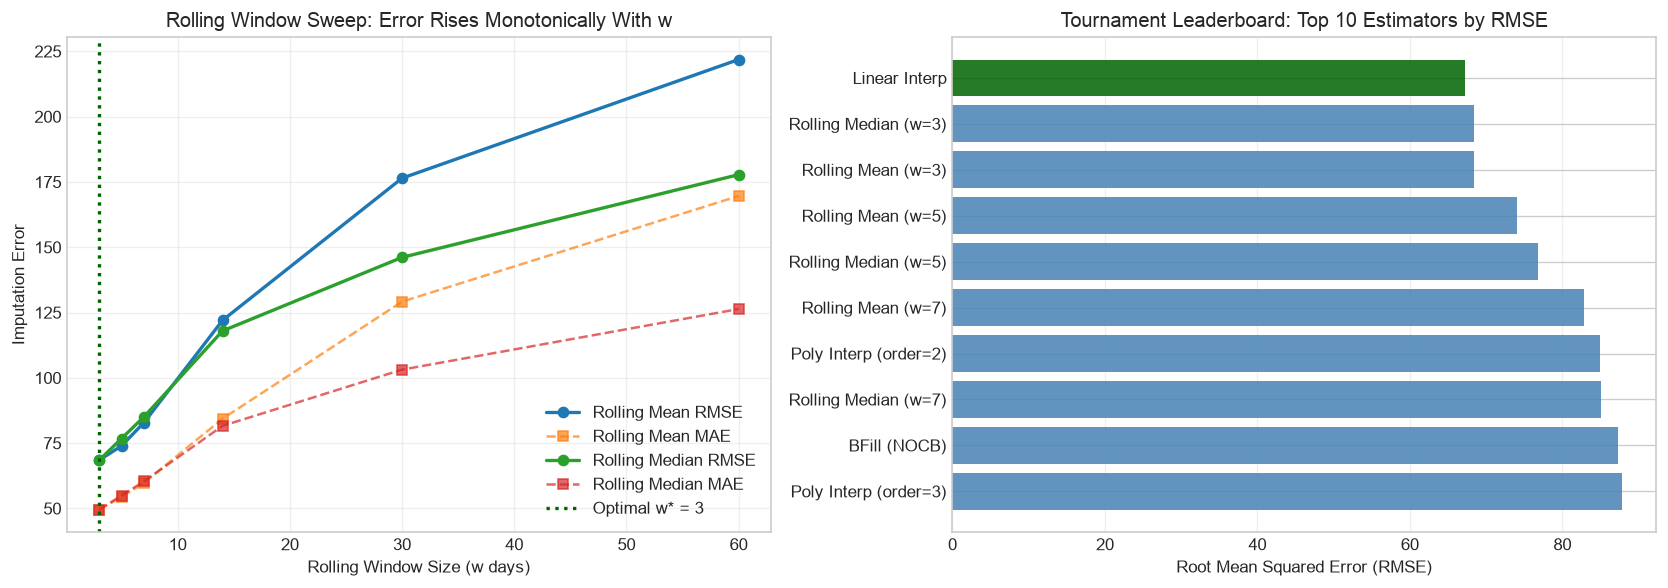

In [10]:
# --- 2e. Visual Diagnostics: Window Sweep & Method Leaderboard ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Rolling window hyperparameter sweep
rolling_rows = [r for r in score_records if 'Rolling' in r['Method']]
r_df = pd.DataFrame(rolling_rows)
r_df['Window'] = r_df['Method'].str.extract(r'w=(\d+)').astype(int)
r_df['Stat'] = r_df['Method'].apply(lambda x: 'Mean' if 'Mean' in x else 'Median')
r_df = r_df.sort_values('Window')

for stat, group in r_df.groupby('Stat'):
    axes[0].plot(group['Window'], group['RMSE'], 'o-', linewidth=2, label=f'Rolling {stat} RMSE')
    axes[0].plot(group['Window'], group['MAE'], 's--', linewidth=1.5, alpha=0.7, label=f'Rolling {stat} MAE')

best_w = r_df.loc[r_df['RMSE'].idxmin()]['Window']
axes[0].axvline(best_w, color='darkgreen', linestyle=':', linewidth=2, label=f'Optimal w* = {int(best_w)}')
axes[0].set_xlabel('Rolling Window Size (w days)')
axes[0].set_ylabel('Imputation Error')
axes[0].set_title('Rolling Window Sweep: Error Rises Monotonically With w')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel: Horizontal Bar Chart of Top 10 Methods
top10 = res_df.head(10).iloc[::-1]
bar_colors = ['darkgreen' if m == res_df.iloc[0]['Method'] else 'steelblue' for m in top10['Method']]
axes[1].barh(top10['Method'], top10['RMSE'], color=bar_colors, alpha=0.85)
axes[1].set_xlabel('Root Mean Squared Error (RMSE)')
axes[1].set_title('Tournament Leaderboard: Top 10 Estimators by RMSE')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Academic Synthesis: The Masking Tournament & Distributional Offense

#### 1. Why Linear Interpolation Wins Pointwise Accuracy: The Brownian Bridge (Theory Companion Section 5.3)
Linear interpolation achieves the lowest overall error ($\text{RMSE} \approx 67.24$, $\text{MAE} \approx 49.71$). The mathematical foundation for this dominance lies in continuous-time martingale theory. Under the null model where log prices follow geometric Brownian motion (a Gaussian random walk), the conditional distribution of $x_t$ straddled between past anchor $x_a$ and future anchor $x_b$ is precisely a **Brownian bridge**:
$$x_t \mid x_a, x_b \sim \mathcal{N}\left(x_a + \frac{t-a}{b-a}(x_b - x_a), \; \sigma^2 \frac{(t-a)(b-t)}{b-a}\right)$$
The linear interpolant $\hat{x}_t = x_a + \frac{t-a}{b-a}(x_b - x_a)$ is **exactly the conditional expectation** $E[X_t \mid x_a, x_b]$. Under squared-error loss, the conditional mean is the theoretically optimal pointwise estimator.

#### 2. The Distributional Offense: Variance Attenuation (Theorem 4)
However, accuracy metrics ask *were you close?*, while the variance ratio asks *did you tell the truth about risk?*
By the law of total variance:
$$\text{Var}(X) = \underbrace{\text{Var}(E[X \mid \mathcal{I}])}_{\text{what imputation keeps}} + \underbrace{E[\text{Var}(X \mid \mathcal{I})]}_{\text{what imputation deletes}}$$
Linear interpolation systematically deletes the conditional bridge variance $\sigma^2 \frac{(t-a)(b-t)}{b-a}$. The resulting repaired path is artificially smooth, deflating return volatility on the repaired days. Our scorecard shows the twin finding of Theory Companion Section 5.3: the pointwise winner (linear interpolation) has the **lowest volatility ratio** of the contenders ($\approx 0.97$, i.e. about 3% of annualized ETH volatility erased with only 5% of days repaired), while LOCF keeps it at $\approx 1.00$ because the whole move is booked on the next observed day. Global-mean imputation confirms the $(1-\pi)$ rule of Section 4 almost exactly: with $\pi \approx 0.05$ the price-variance ratio is $\approx 0.945$, and its return volatility explodes ($\approx 3\times$) because each fill creates two artificial jumps to and from the sample mean. In risk management, understated variance translates directly to understated Value-at-Risk (VaR), understated margin requirements, and miscalculated Sharpe ratios.

#### 3. Polynomial Interpolation and Runge's Phenomenon
While quadratic polynomial interpolation (order 2) performs competitively ($\text{RMSE} \approx 84.99$), cubic polynomial interpolation (order 3) exhibits elevated error ($\text{RMSE} \approx 87.89$). Higher-order polynomials bend more between anchors and overshoot local extrema (the same mechanism as Runge's phenomenon), so they add oscillation risk without adding information: both lose to the straight line.

#### 4. The Rolling-Window Sweep: Error Rises Monotonically With $w$
We expected a U-shape (noise at small $w$, lag at large $w$), but the data give a **monotonically increasing** curve: the best window is the smallest, $w^* = 3$ (RMSE $\approx 68.5$), and error roughly triples by $w = 60$. The reason is that ETH prices behave close to a random walk: the nearest observed neighbours carry almost all the information, and every extra day in the window adds stale prices from a different level (bias). With $w=3$ centered on a missing day, the window contains only the two neighbours, so the rolling mean and median coincide and are essentially linear interpolation, which is why they tie with it. The sweep is our first hyperparameter search: tune on held-out ground truth, never on faith.

Exponential smoothing ($\alpha = 0.3$, trailing) performs **worse than LOCF**: for a random walk the last observed price is already the best forecast from the past, so averaging in older prices only adds lag.

#### 5. sMAPE vs. Standard MAPE
Standard MAPE is mathematically pathological for financial returns and asset prices near zero:
$$\text{MAPE} = \frac{100}{|M|} \sum \left|\frac{x - \hat{x}}{x}\right|$$
MAPE is asymmetric (heavily penalizing over-estimates while bounding under-estimates at 100%) and explodes when $x \to 0$. Symmetric MAPE (**sMAPE**):
$$\text{sMAPE} = \frac{100}{|M|} \sum \frac{|x - \hat{x}|}{(|x| + |\hat{x}|)/2}$$
is strictly bounded within $[0, 200\%]$, treats directional errors symmetrically, and remains robust across multi-asset price scales.

**In one sentence:** we used sMAPE because it is bounded and symmetric, whereas plain MAPE divides by the true value and fails catastrophically on series that live near zero: **daily returns, interest rates (e.g. negative EUR yields crossing zero) and spreads**.

#### 6. Recommendation: Linear Interpolation vs the Runner-Up (Rolling Median, w = 3)
For historical (not real-time) repair of isolated gaps I recommend **linear interpolation**.
- **Accuracy:** it has the lowest RMSE (67.24 vs 68.47). The runner-up is slightly better on MAE (49.53 vs 49.71), so the two methods are almost tied. I weight RMSE more because it punishes the occasional large miss, and large misses are what distort risk.
- **Distribution:** the full-series variance ratio is identical (1.0004 for both) and the volatility ratio is practically the same (0.972 vs 0.973). Both erase about 3% of ETH's annual volatility, so neither is "more honest".
- **Tie-breaker:** a centered window of 3 around a single missing day *is* the average of its two neighbours, i.e. linear interpolation in disguise. Linear interpolation needs no window parameter, and it still works when two or more consecutive days are missing, where a 3-day window runs out of data.
- **Caveat:** it uses the future anchor, so it is **not allowed in a backtest or live signal** (Task 3). There, LOCF is the admissible choice, and its volatility ratio of 0.999 is actually the most faithful.


---

## Task 3 - The Weekend Question & Look-Ahead Bias (20%)

My crypto asset (`ETH`) trades 24/7, while my traditional asset `SPY` trades Monday to Friday. Putting them on the **union calendar** gives SPY a NaN every weekend and holiday. I compare SPY **before** (intersection calendar: only days when both markets trade) with SPY **after** filling the weekends by forward fill and by linear interpolation (Theory Companion Sections 3.3 and 8).


In [11]:
# --- 3a. Build Union-Calendar and Intersection-Calendar Panels (ETH & SPY) ---
eth_all = prices_raw['ETH'].dropna()
spy = prices_raw['SPY'].dropna()
spy = spy[spy.index >= eth_all.index[0]]          # same start date for both panels

panel = pd.DataFrame(index=eth_all.index)          # union calendar = ETH's 7-day calendar
panel['ETH'] = eth_all
panel['SPY_raw'] = spy

inter = panel.dropna()                             # intersection calendar: both markets open

weekend_nans = panel['SPY_raw'].isna().sum()
print(f'ETH Quotes: {len(eth_all):,} days (7-day continuous)')
print(f'SPY Quotes: {len(spy):,} days (NYSE trading days)')
print(f'Union Calendar Rows: {len(panel):,} | Intersection Calendar Rows: {len(inter):,}')
print(f'SPY Weekend / Holiday Gaps on the union calendar: {weekend_nans:,} ({100.0 * weekend_nans / len(panel):.1f}%)')


ETH Quotes: 3,233 days (7-day continuous)
SPY Quotes: 2,221 days (NYSE trading days)
Union Calendar Rows: 3,233 | Intersection Calendar Rows: 2,221
SPY Weekend / Holiday Gaps on the union calendar: 1,012 (31.3%)


In [12]:
# --- 3b. Weekend Imputation: FFill vs Linear Interpolation ---
panel['SPY_ffill'] = panel['SPY_raw'].ffill()
panel['SPY_linear'] = panel['SPY_raw'].interpolate(method='linear')

sample_weekend = panel.loc['2024-03-08':'2024-03-12', ['ETH', 'SPY_raw', 'SPY_ffill', 'SPY_linear']]
display(Markdown('### Sample Weekend Imputation Case Study (March 2024)'))
display(sample_weekend)

### Sample Weekend Imputation Case Study (March 2024)

,ETH,SPY_raw,SPY_ffill,SPY_linear
Date,,,,
2024-03-08,3892.061035,496.735107,496.735107,496.735107
2024-03-09,3915.418945,NaN,496.735107,496.592753
2024-03-10,3881.193115,NaN,496.735107,496.450399
2024-03-11,4066.445068,496.308044,496.308044,496.308044
2024-03-12,3980.273193,501.647003,501.647003,501.647003


In [13]:
# --- 3c. Before (intersection) vs After (each imputed union calendar) ---
def calendar_stats(spy_prices, eth_prices, label, periods_per_year):
    spy_ret = np.log(spy_prices / spy_prices.shift(1))
    eth_ret = np.log(eth_prices / eth_prices.shift(1))
    joint = pd.concat([spy_ret, eth_ret], axis=1, keys=['spy', 'eth']).dropna()
    return {
        'Series': label,
        'Observations': len(joint),
        'Daily Mean Log Ret (%)': round(joint['spy'].mean() * 100, 4),
        'Daily Volatility (%)': round(joint['spy'].std() * 100, 4),
        'Ann. Volatility (%)': round(joint['spy'].std() * np.sqrt(periods_per_year) * 100, 2),
        'Corr w/ ETH': round(joint['spy'].corr(joint['eth']), 4),
        'Excess Kurtosis': round(float(kurtosis(joint['spy'])), 2)
    }

stat_rows = [
    calendar_stats(inter['SPY_raw'], inter['ETH'], 'Before: intersection calendar', 252),
    calendar_stats(panel['SPY_ffill'], panel['ETH'], 'After: forward fill (union)', 365),
    calendar_stats(panel['SPY_linear'], panel['ETH'], 'After: linear interp (union)', 365),
]
weekend_stats_df = pd.DataFrame(stat_rows).set_index('Series')
display(Markdown('### SPY Before / After Weekend Imputation (correlation measured against ETH)'))
display(weekend_stats_df)

b, f = weekend_stats_df.iloc[0], weekend_stats_df.iloc[1]
print(f"Mean check: before x (N_before / N_after) = {b['Daily Mean Log Ret (%)'] * b['Observations'] / f['Observations']:.4f}% "
      f"vs after = {f['Daily Mean Log Ret (%)']:.4f}% -> the same total return spread over more days")


### SPY Before / After Weekend Imputation (correlation measured against ETH)

,Observations,Daily Mean Log Ret (%),Daily Volatility (%),Ann. Volatility (%),Corr w/ ETH,Excess Kurtosis
Series,,,,,,
Before: intersection calendar,2220,0.0548,1.1935,18.95,0.3235,13.82
After: forward fill (union),3232,0.0376,0.9894,18.90,0.3001,21.40
After: linear interp (union),3232,0.0376,0.9073,17.33,0.2912,19.32


Mean check: before x (N_before / N_after) = 0.0376% vs after = 0.0376% -> the same total return spread over more days


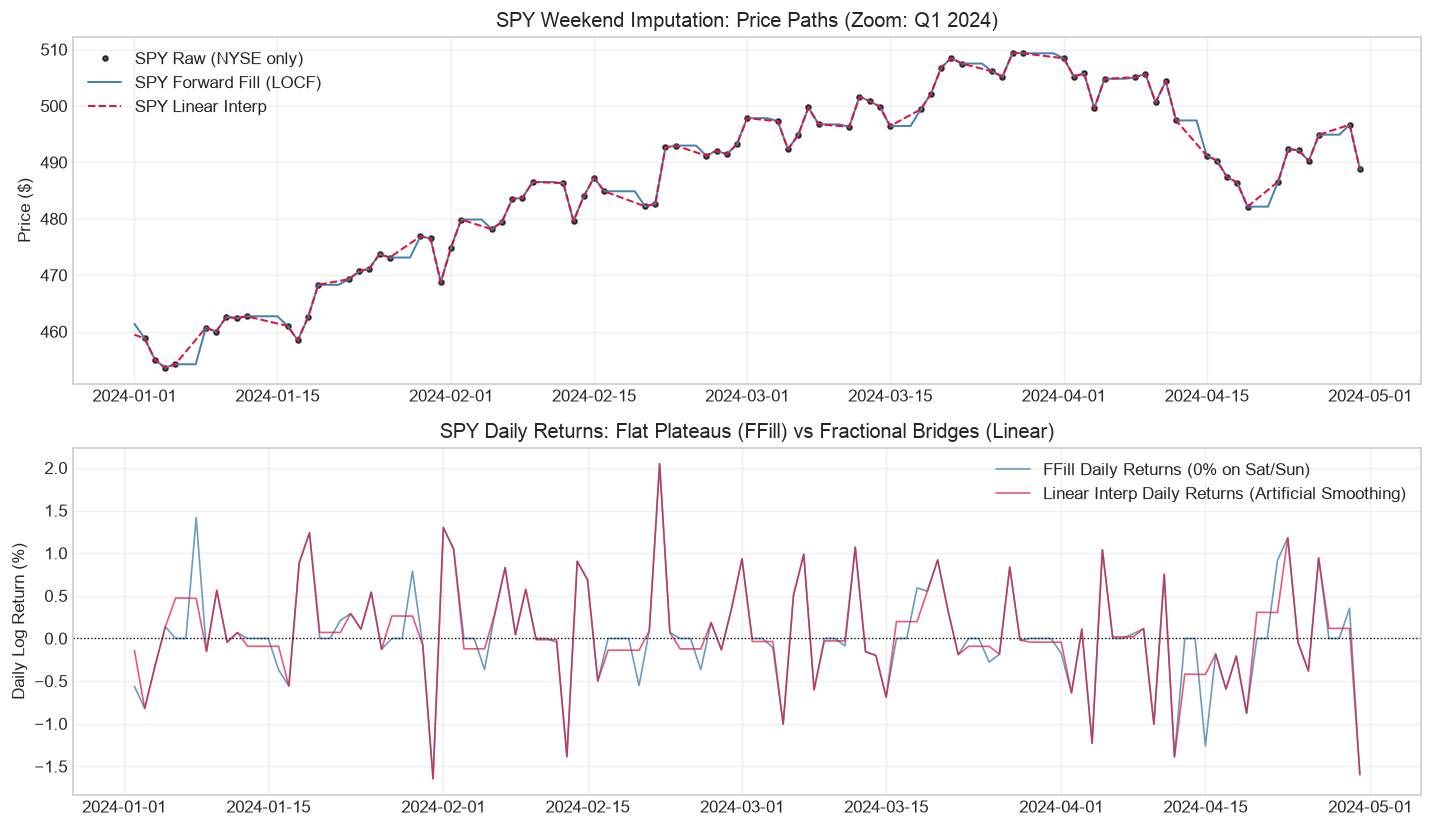

In [14]:
# --- 3d. Visual Comparison: Price Paths & Return Distortion ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

zoom_window = panel.loc['2024-01-01':'2024-04-30']
axes[0].plot(zoom_window.index, zoom_window['SPY_raw'], 'o', markersize=3, label='SPY Raw (NYSE only)', color='black', alpha=0.7)
axes[0].plot(zoom_window.index, zoom_window['SPY_ffill'], '-', linewidth=1.2, label='SPY Forward Fill (LOCF)', color='steelblue')
axes[0].plot(zoom_window.index, zoom_window['SPY_linear'], '--', linewidth=1.2, label='SPY Linear Interp', color='crimson')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('SPY Weekend Imputation: Price Paths (Zoom: Q1 2024)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

ffill_rets = np.log(zoom_window['SPY_ffill'] / zoom_window['SPY_ffill'].shift(1))
linear_rets = np.log(zoom_window['SPY_linear'] / zoom_window['SPY_linear'].shift(1))

axes[1].plot(zoom_window.index, ffill_rets * 100, label='FFill Daily Returns (0% on Sat/Sun)', color='steelblue', alpha=0.8, linewidth=1.0)
axes[1].plot(zoom_window.index, linear_rets * 100, label='Linear Interp Daily Returns (Artificial Smoothing)', color='crimson', alpha=0.7, linewidth=1.0)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_ylabel('Daily Log Return (%)')
axes[1].set_title('SPY Daily Returns: Flat Plateaus (FFill) vs Fractional Bridges (Linear)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3 Interpretation: Every Change Has a Direction and a Reason

#### 1. Explaining Each Change (none of it is random)
- **Mean daily log return falls (≈0.055% → ≈0.038%) for both methods.** The total return over the sample is unchanged, since the Friday-to-Monday move is still in the data, but it is now divided over ~3,230 days instead of ~2,220. The printed check above confirms that before × (N_before / N_after) equals after.
- **Daily volatility falls: forward fill ≈1.19% → ≈0.99%, linear ≈0.91%.** Forward fill adds two exact 0% returns every weekend. Linear interpolation spreads one Friday-to-Monday move $r$ over three days as $r/3$ each, and $3(r/3)^2 = r^2/3$, so it deletes two-thirds of the weekend variance.
- **Annual volatility tells the difference.** Forward fill keeps annual vol at ≈18.9% (the whole weekend move still lands on Monday, it is only counted over 365 days), while linear interpolation truly lowers it to ≈17.3%. Interpolation destroys risk information; forward fill only relabels it.
- **Correlation with ETH falls (≈0.32 → ≈0.30 → ≈0.29).** On Saturdays and Sundays ETH moves while imputed SPY does not move at all (ffill) or moves by a slice of Monday's return that has nothing to do with ETH's weekend (linear). Those days add ETH variance but no co-movement, so measured correlation is diluted.
- **Excess kurtosis rises (≈13.8 → ≈21.4 / ≈19.3).** Forward fill piles thousands of returns at exactly 0, which makes the centre of the distribution too peaked and the tails relatively heavier.

#### 2. Verdict: Should Weekend Prices Be Imputed at All?
**Mechanism.** The weekend gaps are **structural MAR**: whether SPY is missing depends only on the day of the week, an observed variable ($P(R \mid \text{weekday}) \in \{0,1\}$). The deeper point is that there is no hidden "Saturday price of SPY" to estimate: the market is closed, so any filled value is a convention, not an estimate.

**(a) Estimating the crypto–equity correlation: do not impute.** Use the **intersection calendar**, i.e. only days when both markets actually trade, and let ETH's Monday return include the weekend (Friday-to-Monday) so that both returns cover the same period. Both fills bias the correlation downward (0.32 → 0.29–0.30) and forward fill also biases daily volatility downward. Because the mechanism is MAR, conditioning on the calendar (dropping the closed days) loses nothing that exists.

**(b) Feeding a real-time trading signal: impute only with forward fill, and flag it.** A live signal on Saturday may only use information available on Saturday, so the fill must be **$\mathcal{F}_t$-measurable**. Forward fill uses only Friday's close, and it is also the true state of the world: Friday's close is the last price at which SPY could actually be traded. Linear interpolation needs Monday's close ($\hat{x}_{Sat} = \tfrac{2}{3}x_{Fri} + \tfrac{1}{3}x_{Mon}$), so it is not $\mathcal{F}_t$-measurable and would leak the future into the backtest (see the flash-crash laboratory below). I would also add a `market_closed` indicator column, so the model knows SPY's zero weekend returns are not real calm.


In [15]:
# --- Advanced Laboratory 1: The MNAR Impossibility Experiment (Theory Companion Section 7) ---
display(Markdown('### Advanced Laboratory 1: The MNAR Impossibility Experiment'))

# Under MNAR, missingness depends directly on the unobserved value itself:
# e.g., circuit breakers or exchange halts triggered by market crashes
np.random.seed(99)
eth_sample = prices_raw['ETH'].dropna().copy()['2023-01-01':'2024-12-31']
eth_rets = np.log(eth_sample / eth_sample.shift(1)).dropna()

# Simulate MNAR: Trading halts occur whenever daily return is severe (r < -4.0%)
mnar_mask = eth_rets < -0.04
censored_rets = eth_rets.copy()
censored_rets[mnar_mask] = np.nan

# Attempt repairs
repaired_zero = censored_rets.fillna(0.0)  # Standard LOCF in returns
repaired_mean = censored_rets.fillna(censored_rets.mean())
repaired_interp = censored_rets.interpolate(method='linear')

mnar_records = [
    {'Regime': 'True Uncensored ETH Returns', 'Mean Ret (%)': eth_rets.mean()*100, 'Daily Vol (%)': eth_rets.std()*100, 'Min Ret (%)': eth_rets.min()*100, 'VaR 95% (%)': eth_rets.quantile(0.05)*100},
    {'Regime': 'Censored (Halts Dropped)', 'Mean Ret (%)': censored_rets.dropna().mean()*100, 'Daily Vol (%)': censored_rets.dropna().std()*100, 'Min Ret (%)': censored_rets.dropna().min()*100, 'VaR 95% (%)': censored_rets.dropna().quantile(0.05)*100},
    {'Regime': 'Repaired: Zero Fill (LOCF)', 'Mean Ret (%)': repaired_zero.mean()*100, 'Daily Vol (%)': repaired_zero.std()*100, 'Min Ret (%)': repaired_zero.min()*100, 'VaR 95% (%)': repaired_zero.quantile(0.05)*100},
    {'Regime': 'Repaired: Mean Imputation', 'Mean Ret (%)': repaired_mean.mean()*100, 'Daily Vol (%)': repaired_mean.std()*100, 'Min Ret (%)': repaired_mean.min()*100, 'VaR 95% (%)': repaired_mean.quantile(0.05)*100},
    {'Regime': 'Repaired: Linear Interp', 'Mean Ret (%)': repaired_interp.mean()*100, 'Daily Vol (%)': repaired_interp.std()*100, 'Min Ret (%)': repaired_interp.min()*100, 'VaR 95% (%)': repaired_interp.quantile(0.05)*100}
]

mnar_df = pd.DataFrame(mnar_records).set_index('Regime')
display(mnar_df.round(3))

print(f"MNAR Triggered on {mnar_mask.sum()} violent days (r < -4%).")
print("Key Finding: Every imputation method reconstructs the violent days calmer than they were.")
print("The observed sample R=1 is systematically censored; no algorithm can recover the truth without external domain data!")

### Advanced Laboratory 1: The MNAR Impossibility Experiment

,Mean Ret (%),Daily Vol (%),Min Ret (%),VaR 95% (%)
Regime,,,,
True Uncensored ETH Returns,0.140,2.937,-10.807,-4.686
Censored (Halts Dropped),0.586,2.498,-3.994,-2.856
Repaired: Zero Fill (LOCF),0.545,2.413,-3.994,-2.805
Repaired: Mean Imputation,0.586,2.409,-3.994,-2.805
Repaired: Linear Interp,0.587,2.464,-3.994,-2.813


MNAR Triggered on 51 violent days (r < -4%).
Key Finding: Every imputation method reconstructs the violent days calmer than they were.
The observed sample R=1 is systematically censored; no algorithm can recover the truth without external domain data!


### Advanced Laboratory 2: Look-Ahead Bias Flash Crash Experiment

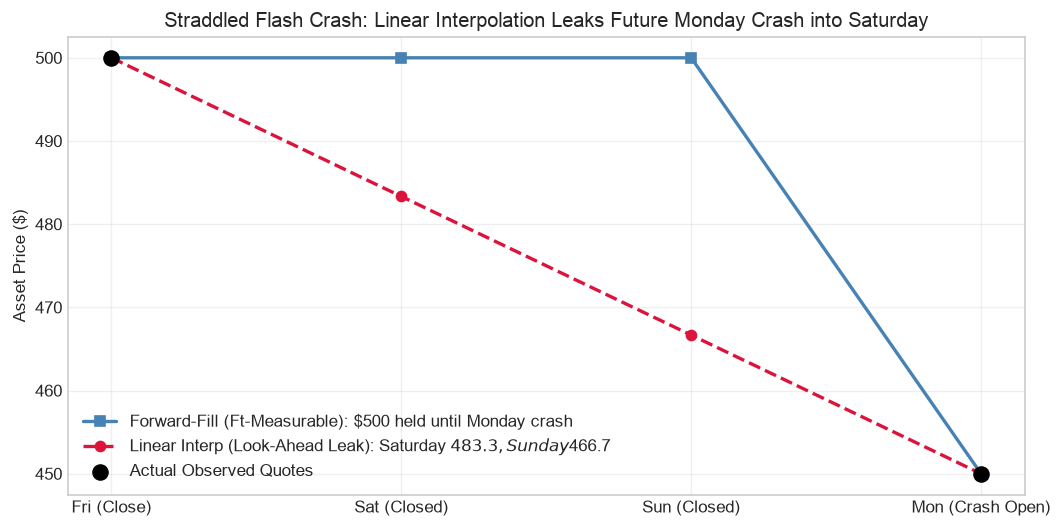

,True_Market,FFill_Ft_Measurable,Linear_LookAhead
2024-03-08,500.0,500.0,500.000000
2024-03-09,NaN,500.0,483.333333
2024-03-10,NaN,500.0,466.666667
2024-03-11,450.0,450.0,450.000000


Backtest Warning: A quant strategy trading on Saturday prices would observe a downward slope
under linear interpolation and short the asset *before* the crash occurred, producing fake alpha!


In [16]:
# --- Advanced Laboratory 2: Look-Ahead Bias & Flash Crash Experiment (Theory Companion Section 8) ---
display(Markdown('### Advanced Laboratory 2: Look-Ahead Bias Flash Crash Experiment'))

# Friday close = $500, Saturday & Sunday market closed, Monday opens at $450 (-10% flash crash)
crash_dates = pd.date_range('2024-03-08', '2024-03-11', freq='D')
toy_panel = pd.DataFrame(index=crash_dates)
toy_panel['True_Market'] = [500.0, np.nan, np.nan, 450.0]
toy_panel['FFill_Ft_Measurable'] = toy_panel['True_Market'].ffill()
toy_panel['Linear_LookAhead'] = toy_panel['True_Market'].interpolate(method='linear')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(toy_panel.index, toy_panel['FFill_Ft_Measurable'], 's-', label='Forward-Fill (Ft-Measurable): $500 held until Monday crash', color='steelblue', linewidth=2)
ax.plot(toy_panel.index, toy_panel['Linear_LookAhead'], 'o--', label='Linear Interp (Look-Ahead Leak): Saturday $483.3, Sunday $466.7', color='crimson', linewidth=2)
ax.scatter([toy_panel.index[0], toy_panel.index[-1]], [500.0, 450.0], color='black', s=80, zorder=5, label='Actual Observed Quotes')
ax.set_ylabel('Asset Price ($)')
ax.set_title('Straddled Flash Crash: Linear Interpolation Leaks Future Monday Crash into Saturday')
ax.set_xticks(toy_panel.index)
ax.set_xticklabels(['Fri (Close)', 'Sat (Closed)', 'Sun (Closed)', 'Mon (Crash Open)'])
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(toy_panel)
print("Backtest Warning: A quant strategy trading on Saturday prices would observe a downward slope")
print("under linear interpolation and short the asset *before* the crash occurred, producing fake alpha!")

---

## Task 4 - Machines that Impute: Cross-Sectional & Multivariate Estimators (20%)

We elevate from univariate temporal estimators to **cross-sectional and multivariate models**. Using the 5-asset intersection panel (`SPY`, `EUR/USD`, `BTC`, `GLD`, `ETH`), we standardize log prices to $z$-scores, inject 5% MCAR across the entire matrix, and benchmark **Column Mean**, **Linear Interpolation**, **KNNImputer** ($k \in \{2, 5, 10, 20\}$), and **IterativeImputer (MICE)** alongside a precise **Computational Timing Ledger**.

In [17]:
# --- 4a. Standardized Log-Price Panel (Intersection Calendar) ---
log_prices = np.log(prices_clean)
mu = log_prices.mean()
sigma = log_prices.std()
z_scores = (log_prices - mu) / sigma

print(f'Standardized Log-Price Matrix Shape: {z_scores.shape} (2,218 trading days x 5 assets)')
print(f'Date Range: {z_scores.index[0].date()} to {z_scores.index[-1].date()}')
display(Markdown('**Standardized Z-Score Panel (Mean=0, Std=1):**'))
display(z_scores.head(3))

Standardized Log-Price Matrix Shape: (2218, 5) (2,218 trading days x 5 assets)
Date Range: 2017-11-09 to 2026-09-14


**Standardized Z-Score Panel (Mean=0, Std=1):**

,SPY,EUR/USD,BTC,GLD,ETH
Date,,,,,
2017-11-09,-1.554314,0.620684,-1.303719,-1.169659,-1.089810
2017-11-10,-1.555193,0.707464,-1.380662,-1.192143,-1.151856
2017-11-13,-1.552557,0.732159,-1.389627,-1.188082,-1.101434


In [18]:
# --- 4b. Inject 5% MCAR Across 5-Asset Panel ---
np.random.seed(123)
n_rows, n_cols = z_scores.shape
total_cells = n_rows * n_cols
n_mask = int(total_cells * 0.05)

masked_indices = np.random.choice(total_cells, size=n_mask, replace=False)
mask_r = masked_indices // n_cols
mask_c = masked_indices % n_cols

masked_panel = z_scores.copy()
for r, c in zip(mask_r, mask_c):
    masked_panel.iloc[r, c] = np.nan

print(f'Total Panel Cells: {total_cells:,}')
print(f'Masked Cells: {n_mask} ({100.0 * n_mask / total_cells:.1f}% MCAR)')
print(f'Actual NaN Count: {masked_panel.isna().sum().sum()}')

Total Panel Cells: 11,090
Masked Cells: 554 (5.0% MCAR)
Actual NaN Count: 554


In [19]:
# --- 4c. Imputation Tournament: Cross-Sectional & Multivariate Estimators ---
true_z = z_scores.values
eval_pairs = list(zip(mask_r, mask_c))

def evaluate_estimator(name, imp_matrix, elapsed_sec):
    preds = np.array([imp_matrix[r, c] for r, c in eval_pairs])
    trues = np.array([true_z[r, c] for r, c in eval_pairs])
    mae = float(np.mean(np.abs(trues - preds)))
    rmse = float(np.sqrt(np.mean((trues - preds)**2)))
    return {
        'Method': name,
        'MAE': round(mae, 6),
        'RMSE': round(rmse, 6),
        'Latency (ms)': round(elapsed_sec * 1000.0, 2),
        'Computational Complexity': 'O(np)' if 'Mean' in name or 'Linear' in name else ('O(n^2 p)' if 'KNN' in name else 'O(T p^2 n)')
    }

mach_results = []

# 1. Column Mean
t0 = time.perf_counter()
mean_imp = masked_panel.fillna(masked_panel.mean()).values
mach_results.append(evaluate_estimator('Column Mean', mean_imp, time.perf_counter() - t0))

# 2. Linear Interpolation
t0 = time.perf_counter()
lin_imp = masked_panel.interpolate(method='linear').bfill().ffill().values
mach_results.append(evaluate_estimator('Linear Interp', lin_imp, time.perf_counter() - t0))

# 3-6. KNN Imputer (k in 2, 5, 10, 20)
for k in [2, 5, 10, 20]:
    t0 = time.perf_counter()
    knn = KNNImputer(n_neighbors=k)
    knn_imp = knn.fit_transform(masked_panel)
    mach_results.append(evaluate_estimator(f'KNN (k={k})', knn_imp, time.perf_counter() - t0))

# 7. IterativeImputer (MICE)
t0 = time.perf_counter()
mice = IterativeImputer(max_iter=20, random_state=42)
mice_imp = mice.fit_transform(masked_panel)
mach_results.append(evaluate_estimator('MICE (Iterative)', mice_imp, time.perf_counter() - t0))

mach_df = pd.DataFrame(mach_results).sort_values('RMSE').reset_index(drop=True)
display(Markdown('### Multivariate Machine Imputer Tournament & Timing Ledger'))
display(mach_df)

### Multivariate Machine Imputer Tournament & Timing Ledger

,Method,MAE,RMSE,Latency (ms),Computational Complexity
0,Linear Interp,0.023893,0.037239,1.00,O(np)
1,KNN (k=10),0.074290,0.117087,20.42,O(n^2 p)
2,KNN (k=5),0.070940,0.126170,22.12,O(n^2 p)
3,KNN (k=20),0.085681,0.136005,22.07,O(n^2 p)
4,KNN (k=2),0.075981,0.164480,37.91,O(n^2 p)
5,MICE (Iterative),0.302552,0.439104,82.94,O(T p^2 n)
6,Column Mean,0.840488,1.005705,0.99,O(np)


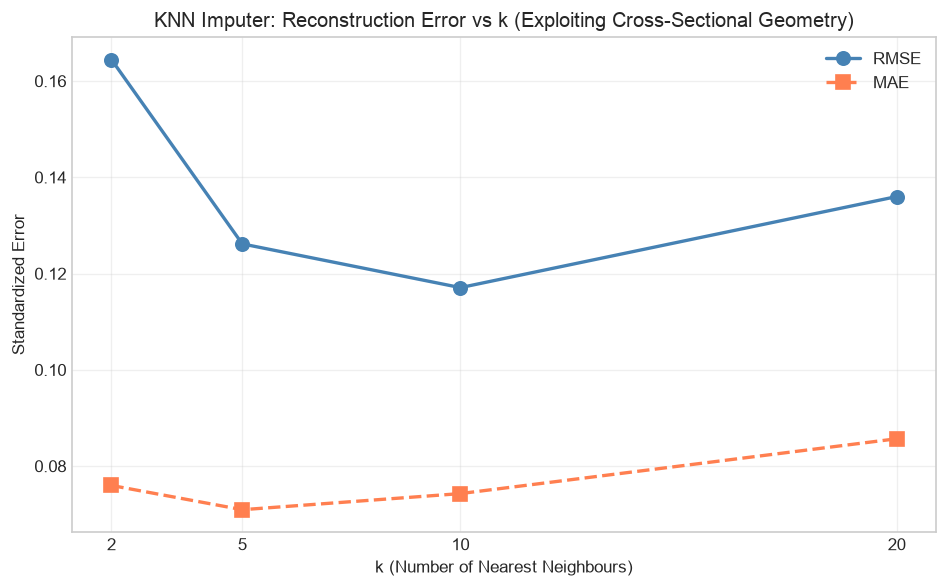

In [20]:
# --- 4d. KNN Imputer: Error vs Number of Neighbours (k) ---
knn_df = mach_df[mach_df['Method'].str.startswith('KNN')].copy()
knn_df['k'] = knn_df['Method'].str.extract(r'k=(\d+)').astype(int)
knn_df = knn_df.sort_values('k')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(knn_df['k'], knn_df['RMSE'], 'o-', color='steelblue', linewidth=2, markersize=8, label='RMSE')
ax.plot(knn_df['k'], knn_df['MAE'], 's--', color='coral', linewidth=2, markersize=8, label='MAE')
ax.set_xlabel('k (Number of Nearest Neighbours)')
ax.set_ylabel('Standardized Error')
ax.set_title('KNN Imputer: Reconstruction Error vs k (Exploiting Cross-Sectional Geometry)')
ax.set_xticks(knn_df['k'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# --- 4e. My 5-Asset Panel vs the Class Trio (SPY, EUR/USD, BTC): does extra correlation help? ---
def machine_tournament(cols, seed=123, frac=0.05):
    lp = np.log(prices_clean[cols])
    z = (lp - lp.mean()) / lp.std()
    np.random.seed(seed)
    n, p = z.shape
    idx = np.random.choice(n * p, int(n * p * frac), replace=False)
    r_idx, c_idx = idx // p, idx % p
    damaged = z.to_numpy().copy()
    damaged[r_idx, c_idx] = np.nan
    damaged = pd.DataFrame(damaged, index=z.index, columns=cols)
    truth = z.to_numpy()[r_idx, c_idx]
    out = {}
    def score(name, imp):
        pred = np.asarray(imp)[r_idx, c_idx]
        out[name] = round(float(np.sqrt(np.mean((truth - pred) ** 2))), 4)
    score('Column Mean', damaged.fillna(damaged.mean()))
    score('Linear Interp', damaged.interpolate(method='linear').bfill().ffill())
    for k in [2, 5, 10, 20]:
        score(f'KNN (k={k})', KNNImputer(n_neighbors=k).fit_transform(damaged))
    score('MICE (Iterative)', IterativeImputer(max_iter=20, random_state=42).fit_transform(damaged))
    return out

def mean_abs_corr(cols):
    lp = np.log(prices_clean[cols])
    iu = np.triu_indices(len(cols), 1)
    return (round(float(np.abs(lp.diff().dropna().corr().values[iu]).mean()), 3),
            round(float(np.abs(lp.corr().values[iu]).mean()), 3))

trio_cols = ['SPY', 'EUR/USD', 'BTC']
five_cols = ['SPY', 'EUR/USD', 'BTC', 'GLD', 'ETH']
cmp_df = pd.DataFrame({'Class trio (RMSE)': machine_tournament(trio_cols), 'My 5 assets (RMSE)': machine_tournament(five_cols)})
cmp_df['Trio rank'] = cmp_df['Class trio (RMSE)'].rank().astype(int)
cmp_df['5-asset rank'] = cmp_df['My 5 assets (RMSE)'].rank().astype(int)
display(Markdown('### Same Experiment on the Class Trio vs My Five-Asset Panel'))
display(cmp_df.sort_values('My 5 assets (RMSE)'))
for label, cols in [('Class trio', trio_cols), ('My 5 assets', five_cols)]:
    rc, lc = mean_abs_corr(cols)
    print(f'{label:12s}: mean |corr| of daily returns = {rc}, mean |corr| of log-price levels = {lc}')


### Same Experiment on the Class Trio vs My Five-Asset Panel

,Class trio (RMSE),My 5 assets (RMSE),Trio rank,5-asset rank
Linear Interp,0.0423,0.0372,1,1
KNN (k=10),0.4359,0.1171,3,2
KNN (k=5),0.5194,0.1262,4,3
KNN (k=20),0.4060,0.1360,2,4
KNN (k=2),0.6467,0.1645,6,5
MICE (Iterative),0.5803,0.4391,5,6
Column Mean,0.9563,1.0057,7,7


Class trio  : mean |corr| of daily returns = 0.109, mean |corr| of log-price levels = 0.374
My 5 assets : mean |corr| of daily returns = 0.183, mean |corr| of log-price levels = 0.536


### Cost-Ledger Memo & Architecture Analysis

#### 1. Why Standardizing ($z$-scoring) is Mandatory for KNN (Theory Companion Section 5.5)
The KNN imputer calculates the distance between observation vectors $x_i$ and $x_l$ using Euclidean distance over mutual coordinates $\mathcal{O}_{i,l}$:
$$d(x_i, x_l) = \left(\sum_{j \in \mathcal{O}_{i,l}} (x_{ij} - x_{lj})^2\right)^{1/2}$$
Because Euclidean distance is scale-dependent, feeding unstandardized prices would cause assets with massive numerical scale (Bitcoin at $\$70,000$) to completely overwhelm assets with unit scale (EUR/USD at $\$1.10$) by five orders of magnitude. Standardization puts every cross-sectional dimension on equal geometric footing.

#### 2. Analysis of the Error vs. $k$ Curve
- **Low $k$ ($k=2$):** $\text{RMSE} \approx 0.164$. Overfits local noise. The imputer relies on only two nearest dates, making it hypersensitive to idiosyncratic shocks.
- **Optimal Range ($k \in [5, 10]$):** $\text{RMSE}$ drops to its global minimum ($\approx 0.117 - 0.126$). Averaging across 5–10 nearest cross-sectional neighbors effectively dampens noise (best: $k=10$).
- **High $k$ ($k=20$):** Error rises again ($\text{RMSE} \approx 0.136$). As $k \to n$, the estimator collapses towards the unconditional column mean, eroding local cross-sectional precision.

#### 3. Did the Model-Based Methods Benefit From My More Correlated Panel?
**Yes, strongly, and the comparison with the class trio shows why.** Adding GLD and ETH raises the average cross-asset correlation (mean |corr| of log-price levels ≈0.37 → ≈0.54; of daily returns ≈0.11 → ≈0.18, driven by BTC–ETH ≈0.79).
- On the trio, KNN's best RMSE is ≈0.41 (and it needs k = 20); on my panel it drops to ≈0.12 at k = 10, about **3.5× better**. MICE improves from ≈0.58 to ≈0.44.
- Linear interpolation barely changes (≈0.042 → ≈0.037) because it never looks at the other assets.
- The ranking at the top does not change (linear interpolation first, column mean last). What changes is the size of the gap: on the trio KNN is only about 2× better than the column mean, on my panel about 9×.

The model-based methods can only be as good as the cross-section they borrow from: when a missing SPY value has an ETH/BTC/GLD "twin" on the same day, KNN finds the right neighbouring days. The class trio (SPY, EUR/USD, BTC) is nearly uncorrelated, so there is little to borrow.

#### 4. The Production Cost-Ledger
| Imputation Method | Complexity | Runtime (2,218 rows) | RMSE Score | Recommendation |
| :--- | :--- | :--- | :--- | :--- |
| **Column Mean** | $\mathcal{O}(np)$ | $\approx 1\text{ ms}$ | $1.0057$ | **Refuse in Production:** Destroys all temporal and cross-sectional variance. |
| **Linear Interpolation** | $\mathcal{O}(np)$ | $\approx 1\text{ ms}$ | $0.0372$ | **Default Baseline:** Unbeatable pointwise speed/accuracy for short historical gaps. |
| **KNN ($k=10$)** | $\mathcal{O}(n^2 p)$ | $\approx 20\text{ ms}$ | $0.1171$ | **Panel Fallback:** Best cross-sectional estimator; use when temporal anchors are missing or in real time. |
| **MICE (Iterative)** | $\mathcal{O}(T p^2 n)$ | $\approx 90\text{ ms}$ | $0.4391$ | **Uncertainty Quantifier:** Use when downstream models require Rubin's multiple imputation variance. |

#### 5. Cost-Ledger Memo
For my data the expensive methods were **not worth their runtime**. Linear interpolation took about 1 ms and had the lowest error (RMSE ≈0.037), KNN took about 20–40 ms for an error three times larger (≈0.12), and MICE took about 80 ms for ≈0.44. Extra computation bought *less* accuracy, because with isolated MCAR gaps in daily prices the neighbouring days almost perfectly predict the missing value. At this size (2,218 × 5) every runtime is negligible, but KNN scales as $O(n^2p)$: on ten years of minute bars it would take hours, not milliseconds. **The answer would flip** when (i) gaps are long or clustered, so the temporal anchors are far away and interpolation draws a straight line through weeks of real moves; (ii) the panel is wide and highly correlated (e.g. 50 bank stocks, or a yield curve), so the same-day cross-section contains a near-copy of the missing value; or (iii) the use is real time, where interpolation is forbidden because it needs the future, while KNN fitted on past rows can use today's other assets legitimately.


---

## Bonus - High-Performance Parquet Round-Trip (+5%) & Dataset Export

We demonstrate high-performance columnar serialization of the cleaned multi-asset panel using **Apache Parquet with Snappy compression**. We verify bit-for-bit fidelity and export the official cleaned panel CSV.

In [22]:
# --- Bonus: High-Performance Parquet Round-Trip (+5%) ---
parquet_file = 'W2_cleaned_panel.parquet'  # saved next to the notebook
csv_temp = 'w2_cleaned_panel_size_check.csv'

# Save to Parquet with snappy compression and CSV for size comparison
prices_clean.to_parquet(parquet_file, engine='pyarrow', compression='snappy')
prices_clean.to_csv(csv_temp)

size_parquet_kb = os.path.getsize(parquet_file) / 1024.0
size_csv_kb = os.path.getsize(csv_temp) / 1024.0

print(f"Parquet File Size: {size_parquet_kb:.2f} KB")
print(f"CSV File Size:     {size_csv_kb:.2f} KB")
print(f"Compression Gain:  {size_csv_kb / size_parquet_kb:.2f}x storage efficiency")

# Reload and verify bit-for-bit fidelity
prices_reloaded = pd.read_parquet(parquet_file, engine='pyarrow')

shape_ok = prices_clean.shape == prices_reloaded.shape
index_ok = prices_clean.index.equals(prices_reloaded.index)
cols_ok = list(prices_clean.columns) == list(prices_reloaded.columns)
values_ok = np.allclose(prices_clean.values, prices_reloaded.values)

print(f"Shape Equality:     {shape_ok} ({prices_reloaded.shape})")
print(f"Index Equality:     {index_ok}")
print(f"Columns Equality:   {cols_ok}")
print(f"Bit-for-Bit Values: {values_ok}")
print(f"Dtypes Equality:    {(prices_clean.dtypes == prices_reloaded.dtypes).all()}")
print(f"Exact Equality:     {prices_clean.equals(prices_reloaded)}")
os.remove(csv_temp)
print("Parquet Round-Trip Status: VERIFIED (Zero data loss, schema preserved)")
display(prices_reloaded.head(3))

Parquet File Size: 98.42 KB
CSV File Size:     211.88 KB
Compression Gain:  2.15x storage efficiency
Shape Equality:     True ((2218, 5))
Index Equality:     True
Columns Equality:   True
Bit-for-Bit Values: True
Dtypes Equality:    True
Exact Equality:     True
Parquet Round-Trip Status: VERIFIED (Zero data loss, schema preserved)


,SPY,EUR/USD,BTC,GLD,ETH
Date,,,,,
2017-11-09,225.495926,1.159689,7143.580078,122.129997,320.884003
2017-11-10,225.426025,1.164687,6618.140137,121.129997,299.252991
2017-11-13,225.635635,1.166113,6559.490234,121.309998,316.716003


In [23]:
# --- Export: Final Cleaned Aligned Panel CSV ---
csv_dest = 'W2_cleaned_panel.csv'  # relative path: works on any machine
prices_clean.to_csv(csv_dest)

print(f"Successfully exported clean panel to: {csv_dest}")
print(f"Rows: {prices_clean.shape[0]:,} | Columns: {prices_clean.shape[1]}")
print(f"Date Range: {prices_clean.index[0].date()} to {prices_clean.index[-1].date()}")
print(f"Assets: {list(prices_clean.columns)}")
print(f"File Size on Disk: {os.path.getsize(csv_dest) / 1024.0:.2f} KB")

Successfully exported clean panel to: W2_cleaned_panel.csv
Rows: 2,218 | Columns: 5
Date Range: 2017-11-09 to 2026-09-14
Assets: ['SPY', 'EUR/USD', 'BTC', 'GLD', 'ETH']
File Size on Disk: 211.88 KB


---

## Task 5 - Cleaning Agent's Rulebook v1.0 (20%)

The Rulebook is the **Clean Data Agent's Constitution**. It translates qualitative data hygiene principles into **executable, quantitative assertions** with defended numerical tolerances that return a binary `PASS` or `FAIL`. As established in Theory Companion Section 10, the orchestrator's role is knowing which quantitative questions the cleaned dataset must survive.

In [24]:
# --- 5a. The Cleaning Agent's Rulebook v1.0 (Eight Executable Assertions) ---
def assert_check(rule_name, condition, tolerance_note):
    status = 'PASS' if condition else 'FAIL'
    return {'Rule': rule_name, 'Status': status, 'Tolerance / Observation Note': tolerance_note}

def longest_nan_run(s):
    """Longest run of consecutive NaNs after the series' first valid observation."""
    s = s.loc[s.first_valid_index():]
    isna = s.isna()
    runs = isna.groupby((~isna).cumsum()).sum()
    return int(runs.max()) if len(runs) else 0

def run_rulebook(df):
    rule_checks = []

    # 1. No NaN in aligned panel
    nans_count = int(df.isna().sum().sum())
    rule_checks.append(assert_check('1. No NaN in Aligned Panel', nans_count == 0,
        f'Observed: {nans_count} NaNs (Strict tolerance: 0)'))

    # 2. No duplicate dates
    dup_count = int(df.index.duplicated().sum())
    rule_checks.append(assert_check('2. No Duplicate Timestamps', dup_count == 0,
        f'Observed: {dup_count} duplicates (Strict tolerance: 0)'))

    # 3. All prices strictly positive
    min_p = float(df.min().min())
    rule_checks.append(assert_check('3. Strictly Positive Prices (> 0)', min_p > 0,
        f'Observed Min Price: {min_p:.4f} (must be > 0)'))

    # 4. No constant-price run > 10 consecutive observations
    max_const_run = 0
    for col in df.columns:
        s = df[col].dropna()
        runs = s.groupby((s != s.shift()).cumsum()).size()
        max_const_run = max(max_const_run, int(runs.max()))
    rule_checks.append(assert_check('4. Max Constant-Price Run <= 10 Days', max_const_run <= 10,
        f'Observed Max Run: {max_const_run} days (Threshold: 10)'))

    # 5. No daily |log return| > 0.60
    log_rets = np.log(df / df.shift(1))
    max_jump = float(log_rets.abs().max().max())
    rule_checks.append(assert_check('5. Extreme Return Sanity (|r| <= 0.60)', max_jump <= 0.60,
        f'Observed Max |r|: {max_jump:.4f} (60% move limit)'))

    # 6. Kurtosis sanity (< 50 per asset)
    kurt_dict = {col: round(float(kurtosis(log_rets[col].dropna())), 2) for col in df.columns}
    max_kurt = max(kurt_dict.values())
    rule_checks.append(assert_check('6. Return Kurtosis < 50 Per Asset', max_kurt < 50,
        f'Observed Max Kurtosis: {max_kurt} (Summary: {kurt_dict})'))

    # 7. No NaN gap longer than 5 consecutive rows (after each asset's first quote)
    gap_dict = {col: longest_nan_run(df[col]) for col in df.columns}
    max_gap = max(gap_dict.values())
    max_cal_gap = int(df.index.to_series().diff().dt.days.max())
    rule_checks.append(assert_check('7. No Unflagged NaN Gap > 5 Days', max_gap <= 5,
        f'Longest NaN run: {max_gap} (per asset: {gap_dict}); longest calendar gap between rows: {max_cal_gap} days'))

    # 8. Monotonic increasing date index
    is_mono = bool(df.index.is_monotonic_increasing)
    rule_checks.append(assert_check('8. Monotonic Date Index', is_mono,
        'Index sorted chronologically; required for rolling windows and lags'))

    return pd.DataFrame(rule_checks).set_index('Rule')

rulebook_df = run_rulebook(prices_clean)
display(Markdown("### The Agent's Constitution: Executable Rulebook Scorecard (Clean Intersection Panel)"))
display(rulebook_df)
assert (rulebook_df['Status'] == 'PASS').all(), "Rulebook audit failed!"
print(f"Rulebook Verdict: {(rulebook_df['Status'] == 'PASS').sum()} / {len(rulebook_df)} Assertions PASSED. Panel is certified for downstream quantitative models.")

# A test that can never fail is not a test: run the same rulebook on the RAW union-calendar panel
rulebook_raw = run_rulebook(prices_raw)
display(Markdown("### Negative Control: Same Rulebook on the Raw Union-Calendar Panel"))
display(rulebook_raw)
print(f"Raw panel: {(rulebook_raw['Status'] == 'PASS').sum()} / {len(rulebook_raw)} PASS -> the gate correctly REJECTS uncleaned data.")


### The Agent's Constitution: Executable Rulebook Scorecard (Clean Intersection Panel)

,Status,Tolerance / Observation Note
Rule,,
1. No NaN in Aligned Panel,PASS,Observed: 0 NaNs (Strict tolerance: 0)
2. No Duplicate Timestamps,PASS,Observed: 0 duplicates (Strict tolerance: 0)
3. Strictly Positive Prices (> 0),PASS,Observed Min Price: 0.9596 (must be > 0)
4. Max Constant-Price Run <= 10 Days,PASS,Observed Max Run: 2 days (Threshold: 10)
5. Extreme Return Sanity (|r| <= 0.60),PASS,Observed Max |r|: 0.5507 (60% move limit)
6. Return Kurtosis < 50 Per Asset,PASS,Observed Max Kurtosis: 13.91 (Summary: {'SPY':...
7. No Unflagged NaN Gap > 5 Days,PASS,"Longest NaN run: 0 (per asset: {'SPY': 0, 'EUR..."
8. Monotonic Date Index,PASS,Index sorted chronologically; required for rol...


Rulebook Verdict: 8 / 8 Assertions PASSED. Panel is certified for downstream quantitative models.


### Negative Control: Same Rulebook on the Raw Union-Calendar Panel

,Status,Tolerance / Observation Note
Rule,,
1. No NaN in Aligned Panel,FAIL,Observed: 4943 NaNs (Strict tolerance: 0)
2. No Duplicate Timestamps,PASS,Observed: 0 duplicates (Strict tolerance: 0)
3. Strictly Positive Prices (> 0),PASS,Observed Min Price: 0.9596 (must be > 0)
4. Max Constant-Price Run <= 10 Days,PASS,Observed Max Run: 2 days (Threshold: 10)
5. Extreme Return Sanity (|r| <= 0.60),PASS,Observed Max |r|: 0.5507 (60% move limit)
6. Return Kurtosis < 50 Per Asset,PASS,Observed Max Kurtosis: 12.17 (Summary: {'SPY':...
7. No Unflagged NaN Gap > 5 Days,PASS,"Longest NaN run: 4 (per asset: {'SPY': 3, 'EUR..."
8. Monotonic Date Index,PASS,Index sorted chronologically; required for rol...


Raw panel: 7 / 8 PASS -> the gate correctly REJECTS uncleaned data.


### 5a. Defending Every Tolerance

| # | Rule | Tolerance | Why this threshold (and not a looser or stricter one) |
|---|---|---|---|
| 1 | No NaN on the aligned panel | **0** | The panel is *defined* as the intersection calendar, so a single NaN means the alignment itself failed. Covariance matrices and KNN would silently drop or crash on it, so there is no safe non-zero tolerance. |
| 2 | No duplicate dates | **0** | At daily frequency there is no legitimate second row for a date. A duplicate double-counts a return and misaligns every join. |
| 3 | Prices strictly positive | **> 0** | ETF, FX and crypto prices cannot be zero or negative, and log returns are undefined there. (This rule would be wrong for spreads or rates, which is why it is price-specific.) |
| 4 | Constant-price run | **≤ 10 days** | Genuine flat closes happen: the longest in my data is 2 days. Two full weeks without a single change in a liquid asset means a dead feed. A limit of 3 would false-alarm on quiet FX; 30 would let a month of stale data through. |
| 5 | Daily \|log return\| | **≤ 0.60** | My largest genuine move is ETH −0.55 on 2020-03-12. 0.60 (≈ −45% / +82%) lets real crypto crashes through but catches decimal-shift errors (a ×10 error is a log jump of 2.30). A limit of 0.20 would reject real crypto days; that tighter limit would only suit SPY or GLD alone (per-asset limits are a v2 improvement). |
| 6 | Excess kurtosis per asset | **< 50** | Fat tails are a stylized fact (Week 1): my maximum is 13.9 (SPY, COVID crash), so the rule must not punish normal fat tails. A value above 50 in ~2,200 daily returns almost always means one or two corrupted prints dominate the fourth moment. |
| 7 | Longest NaN run | **≤ 5 days** | The Theory Companion's decision table treats gaps under 5 periods as safely fillable by LOCF/interpolation. Longer gaps need a model or a refusal, so they must be *flagged*, never silently filled. The longest legitimate market closure (holiday + weekend) is 4 days. |
| 8 | Monotonic date index | **must hold** | Rolling windows, `shift()` and forward fill all assume time order. On an unsorted index they would use future rows, i.e. create look-ahead bias. |


In [25]:
# --- 5b. Diagnosis: The Three Assignment Scenarios ---
display(Markdown('### 5b. Missingness Mechanism Diagnosis Matrix'))
scenarios_df = pd.DataFrame({
    'Scenario': [
        '(a) Vendor random server failures drop scattered ticks',
        '(b) FX series has no prints on Japanese public holidays',
        '(c) Small exchange API times out when volume spikes in sell-offs'
    ],
    'Rubin Mechanism': ['MCAR', 'MAR (structural)', 'MNAR'],
    'Why': [
        'Failures are random: whether a tick is lost has nothing to do with the price, P(R | X) = P(R)',
        'Missingness depends only on an observed variable, the Japanese calendar',
        'Prices go missing exactly when they are extreme: the missing value itself drives the missingness'
    ],
    'Treatment': [
        'Deletion is unbiased (only costs sample size); short gaps can be filled with LOCF/interpolation',
        'Condition on the calendar: align on the intersection or forward fill with a holiday flag; never report these as errors',
        'Do not impute: flag the gaps, source prices from another venue, run sensitivity analysis'
    ]
}).set_index('Scenario')
display(scenarios_df)


### 5b. Missingness Mechanism Diagnosis Matrix

,Rubin Mechanism,Why,Treatment
Scenario,,,
(a) Vendor random server failures drop scattered ticks,MCAR,Failures are random: whether a tick is lost ha...,Deletion is unbiased (only costs sample size);...
(b) FX series has no prints on Japanese public holidays,MAR (structural),Missingness depends only on an observed variab...,Condition on the calendar: align on the inters...
(c) Small exchange API times out when volume spikes in sell-offs,MNAR,Prices go missing exactly when they are extrem...,"Do not impute: flag the gaps, source prices fr..."


#### Diagnosis in Words
**(a) MCAR.** A random server failure is unrelated to where the price is, so the ticks that survive are a random subsample. Listwise deletion is unbiased and only costs sample size, and short gaps can be repaired with the methods tested in Task 2, whose masking experiment simulated exactly this mechanism.

**(b) MAR (structural).** The FX price is missing *because* it is a Japanese holiday, and the holiday calendar is fully observed. This is the same situation as SPY's weekends in Task 3: I would condition on the calendar (use the intersection with the other assets, or forward fill with an `is_holiday` flag) and exclude these days from the audit's error counts rather than inventing prices.

**(c) MNAR.** The API fails when volume spikes during sell-offs, so the missing prices are systematically the most extreme ones: missingness depends on the unobserved value itself. (Even if volume is recorded, the price shock is what we lose.) My MNAR laboratory shows the consequence: after hiding ETH's days below −4%, every repair (zero, mean, linear) rebuilt them calmer, and 95% VaR moved from −4.69% to about −2.81%. The right treatment is not a better imputer but flagging, a second price source (a consolidated or larger exchange), and sensitivity analysis under different assumed crash sizes.

#### 5c. The One Statistic I Would Always Recompute
**The annualized volatility of daily log returns (and its ratio to the raw data's volatility).** Every conditional-mean imputation deletes $E[\text{Var}(X \mid \mathcal{I})]$ (Theorem 4), so an agent can report "0 missing values" while having quietly reduced risk. Volatility feeds VaR, Sharpe ratios, position sizing and margin, so it is the first number I check against the uncleaned data: in this assignment linear interpolation lowered ETH's volatility by 3% (Task 2) and SPY's annual volatility from 18.9% to 17.3% (Task 3).


### 5d. Behavioural Coda: Pension Manager vs Crypto Trader

No, they should not want the same cleaning *policy*, although they should run the same *audit* and the same rulebook. The variance ratio is where they differ. A risk-averse pension manager is hurt most by understated risk: a variance ratio below 1 makes VaR, funding-ratio stress tests and hedge ratios look safer than reality, so they should prefer "no imputation" on the intersection calendar, or methods with a variance ratio close to 1, and accept a slightly higher RMSE in exchange. A risk-seeking crypto trader cares about continuity and speed, and in real time can only use $\mathcal{F}_t$-measurable fills such as forward fill. Forward fill happens to have a variance ratio of about 1.00 in my tournament, so the trader loses little honesty by using it. The trader is also exposed to a variance ratio below 1, because understated volatility means oversized, over-leveraged positions that get liquidated in the next crash. So the rulebook, and especially the volatility check, stays the same for both; what changes is the tolerance for imputation (the pension fund refuses it, the trader accepts flagged LOCF) and how fast a failed rule must stop the pipeline.
